In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt


import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['figure.figsize'] = (8,6)
mpl.rcParams['xtick.labelsize'] = 20
mpl.rcParams['ytick.labelsize'] = 20
mpl.rcParams['axes.grid'] = True
mpl.rcParams['axes.grid.which'] = 'both'
mpl.rcParams['grid.color'] = 'grey'
mpl.rcParams['grid.alpha'] = 0.2
mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['axes.labelsize'] = 22
mpl.rcParams['legend.handlelength'] = 3
mpl.rcParams['legend.fontsize'] = 20
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
mpl.rcParams['xtick.top'] = True      # show ticks on the top axis
mpl.rcParams['ytick.right'] = True    # show ticks on the right axis

from matplotlib import rc
rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
rc('text', usetex=True)

In [2]:
import numpy as np
from scipy.stats import truncnorm

def sample_joint_gaussian_component_spins(n_binaries, mu_a, sigma_a, mu_t, sigma_t, zeta):
    """
    Samples from the 2D joint distribution of the Gaussian Component Spins model.
    """
    # 1. Spin Magnitudes: These are independent of each other and the tilts
    a_lower = (0.0 - mu_a) / sigma_a
    a_upper = (1.0 - mu_a) / sigma_a
    
    a1 = truncnorm.rvs(a_lower, a_upper, loc=mu_a, scale=sigma_a, size=n_binaries)
    a2 = truncnorm.rvs(a_lower, a_upper, loc=mu_a, scale=sigma_a, size=n_binaries)

    # 2. Spin Tilts: Jointly dependent on the binary formation channel
    # Flip one coin per BINARY to determine its channel
    is_gaussian_binary = np.random.binomial(1, zeta, size=n_binaries).astype(bool)
    
    cost1 = np.empty(n_binaries)
    cost2 = np.empty(n_binaries)

    # Populate the aligned channel (BOTH spins get a Truncated Gaussian)
    n_gauss = np.sum(is_gaussian_binary)
    if n_gauss > 0:
        t_lower = (-1.0 - mu_t) / sigma_t
        t_upper = (1.0 - mu_t) / sigma_t
        
        cost1[is_gaussian_binary] = truncnorm.rvs(t_lower, t_upper, loc=mu_t, scale=sigma_t, size=n_gauss)
        cost2[is_gaussian_binary] = truncnorm.rvs(t_lower, t_upper, loc=mu_t, scale=sigma_t, size=n_gauss)

    # Populate the dynamic channel (BOTH spins get a Uniform)
    n_iso = n_binaries - n_gauss
    if n_iso > 0:
        cost1[~is_gaussian_binary] = np.random.uniform(-1.0, 1.0, size=n_iso)
        cost2[~is_gaussian_binary] = np.random.uniform(-1.0, 1.0, size=n_iso)

    return a1, a2, cost1, cost2

In [3]:
mu_chi      =  0.103545
sigma_chi   =  0.339752
mu_spin       =  0.228621
sigma_spin    =  0.530840
xi_spin       =  0.940896

In [4]:
chi1, chi2, cost1, cost2 = sample_joint_gaussian_component_spins(
    n_binaries=100000,
    mu_a=mu_chi, sigma_a=sigma_chi,
    mu_t=mu_spin, sigma_t=sigma_spin,
    zeta=xi_spin
)

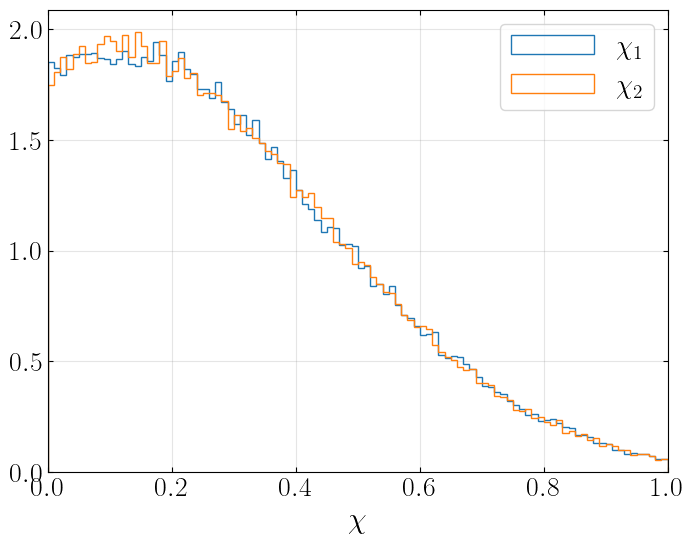

In [5]:
plt.hist(chi1, bins=100, density=True, histtype='step', label=r'$\chi_1$')
plt.hist(chi2, bins=100, density=True, histtype='step', label=r'$\chi_2$')
plt.xlabel(r'$\chi$')
plt.xlim(0.,1.)
plt.legend()
plt.savefig('spin_magnitudes.png', dpi=300)

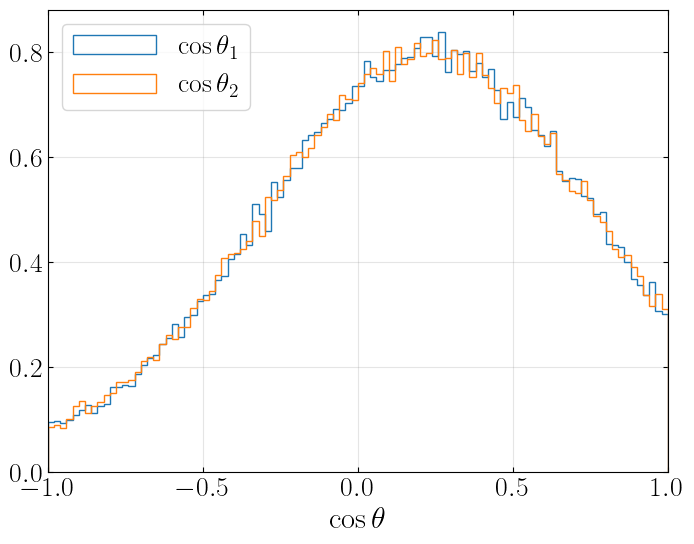

In [6]:
plt.hist(cost1, bins=100, density=True, histtype='step', label=r'$\cos\theta_1$')
plt.hist(cost2, bins=100, density=True, histtype='step', label=r'$\cos\theta_2$')
plt.xlabel(r'$\cos\theta$')
plt.xlim(-1.,1.)
plt.legend()
plt.savefig('spin_tilts.png', dpi=300)

In [7]:
from gwpopulation.models.spin import iid_spin_orientation_gaussian_isotropic
from gwpopulation.utils import truncnorm
from bilby.core.prior import Interped
import numpy as np

In [8]:
spin_hyperpars = {'mu_chi': 0.103545,
                   'sigma_chi': 0.339752,
                   'mu_spin': 0.228621,
                  'sigma_spin': 0.530840,
                   'xi_spin': 0.940896}
# Median values
#spin_hyperpars = {'mu_chi': 0.1,
#                  'sigma_chi': 0.306,
#                  'mu_spin': 0.4622,
#                  'sigma_spin': 1.3768,
#                  'xi_spin': 0.62392}

In [9]:
def sample_spin(num_samples, 
                mu_chi=spin_hyperpars['mu_chi'], 
                sigma_chi=spin_hyperpars['sigma_chi'], 
                mu_spin=spin_hyperpars['mu_spin'], 
                sigma_spin=spin_hyperpars['sigma_spin'], 
                xi_spin=spin_hyperpars['xi_spin'], 
                a_range = (0, 0.99),
                cos_tilt_range = (-1, 1)):
    num_samples = int(num_samples)
    a_i = np.random.uniform(a_range[0], a_range[1], 10000)
    dataset_i = {'cos_tilt_1': np.linspace(cos_tilt_range[0], cos_tilt_range[1], 10000),
                 'cos_tilt_2': np.linspace(cos_tilt_range[0], cos_tilt_range[1], 10000)}
    
    prob_ai = truncnorm(a_i, mu=mu_chi, sigma=sigma_chi, high=1, low=0)
    p_a = Interped(a_i, prob_ai, minimum=a_range[0], maximum=a_range[1])
    
    prob_cos_tilt = iid_spin_orientation_gaussian_isotropic(dataset=dataset_i, 
                                                            xi_spin=xi_spin, 
                                                            sigma_spin=sigma_spin, 
                                                            mu_spin=mu_spin)
    norm = np.trapz(prob_cos_tilt, dataset_i['cos_tilt_1'])
    prob_cos_tilt /= norm
    p_cos_tilt = Interped(dataset_i['cos_tilt_1'], prob_cos_tilt, 
                          minimum=cos_tilt_range[0], 
                          maximum=cos_tilt_range[1])
    
    samples = {'a_1': p_a.sample(num_samples),
               'a_2': p_a.sample(num_samples),
               'tilt_1': np.arccos(p_cos_tilt.sample(num_samples)),
               'tilt_2': np.arccos(p_cos_tilt.sample(num_samples))}
    return(samples)

In [10]:
my_samples = sample_spin(1e5)

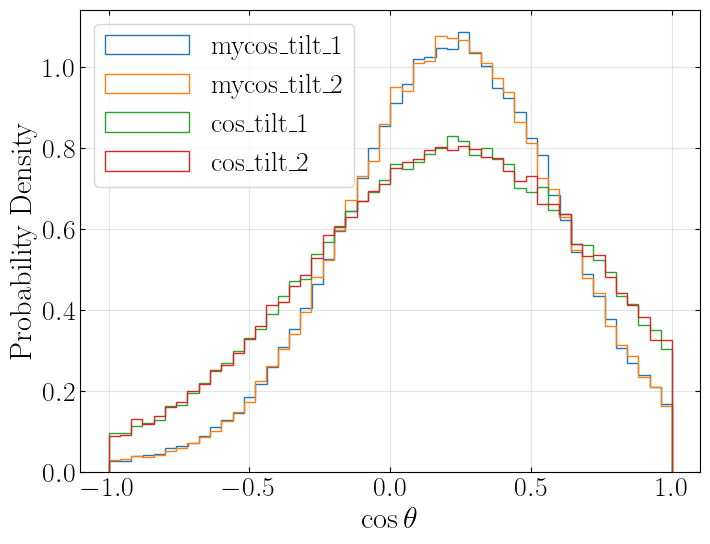

In [11]:
plt.hist(np.cos(my_samples['tilt_1']), density=True, bins=50, histtype='step', label='mycos_tilt_1');
plt.hist(np.cos(my_samples['tilt_2']), density=True, bins=50, histtype='step', label='mycos_tilt_2');
plt.hist(cost1, density=True, bins=50, histtype='step', label='cos_tilt_1');
plt.hist(cost2, density=True, bins=50, histtype='step', label='cos_tilt_2');
plt.xlabel(r'$\cos \theta$')
plt.ylabel('Probability Density')
plt.legend()
plt.show()

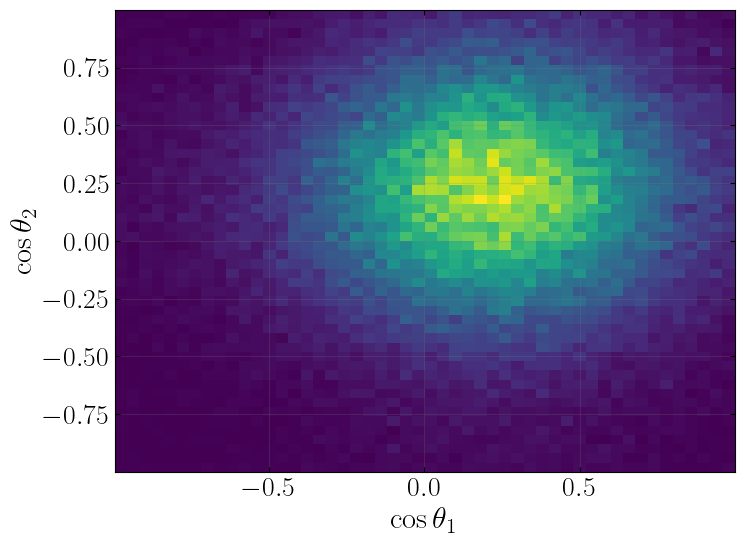

In [12]:
plt.hist2d(np.cos(my_samples['tilt_1']), np.cos(my_samples['tilt_2']), bins=50, density=True)
#plt.hist2d(cost1, cost2, bins=50, density=True)
#plt.hist2d(costs[:,0], costs[:,1], bins=50, density=True)
plt.xlabel(r'$\cos\theta_1$')
plt.ylabel(r'$\cos\theta_2$')
plt.show()

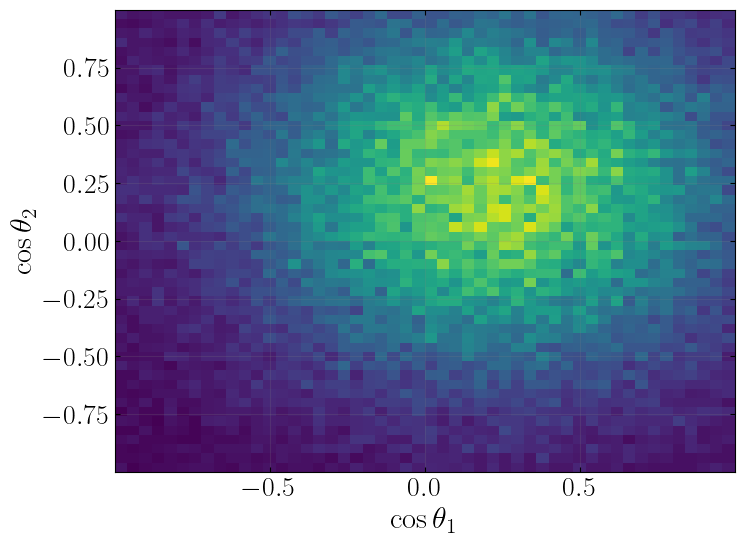

In [13]:
plt.hist2d(cost1, cost2, bins=50, density=True)
#plt.hist2d(costs[:,0], costs[:,1], bins=50, density=True)
plt.xlabel(r'$\cos\theta_1$')
plt.ylabel(r'$\cos\theta_2$')
plt.show()

In [14]:
import numpy as np
from scipy.stats import truncnorm
from gwpopulation.models.spin import independent_spin_orientation_gaussian_isotropic

def sample_gwpop_gaussian_component(n_binaries, mu_a, sigma_a, mu_t, sigma_t, zeta):
    """
    Samples the Gaussian Component Spins model by directly evaluating the 
    native gwpopulation 2D joint probability functions.
    """
    
    # ---------------------------------------------------------
    # 1. Spin Magnitudes (Independent)
    # Since these are fully independent Truncated Normals, 
    # scipy is mathematically exact and much faster than rejection sampling.
    # ---------------------------------------------------------
    a_lower = (0.0 - mu_a) / sigma_a
    a_upper = (1.0 - mu_a) / sigma_a
    
    a1 = truncnorm.rvs(a_lower, a_upper, loc=mu_a, scale=sigma_a, size=n_binaries)
    a2 = truncnorm.rvs(a_lower, a_upper, loc=mu_a, scale=sigma_a, size=n_binaries)

    # ---------------------------------------------------------
    # 2. Spin Tilts (Joint 2D Rejection Sampling)
    # We use gwpopulation to calculate the true 2D probability surface
    # ---------------------------------------------------------
    accepted_ct1 = []
    accepted_ct2 = []
    
    # Find the maximum possible probability height (the peak of the 2D Gaussian)
    # This happens when both spins sit exactly at mu_t
    max_dataset = {'cos_tilt_1': np.array([mu_t]), 'cos_tilt_2': np.array([mu_t])}
    max_p = independent_spin_orientation_gaussian_isotropic(
        max_dataset, 
        xi_spin=zeta, 
        sigma_1=sigma_t, sigma_2=sigma_t, 
        mu_1=mu_t, mu_2=mu_t
    )[0] # Extract the single float value

    # We propose large batches of random pairs to speed up the loop
    batch_size = n_binaries * 5 
    
    while len(accepted_ct1) < n_binaries:
        # Step A: Propose random uniform pairs in 2D space
        prop_ct1 = np.random.uniform(-1, 1, batch_size)
        prop_ct2 = np.random.uniform(-1, 1, batch_size)
        
        # Step B: Evaluate the true joint probability of these pairs using gwpopulation
        dataset_prop = {'cos_tilt_1': prop_ct1, 'cos_tilt_2': prop_ct2}
        p_joint = independent_spin_orientation_gaussian_isotropic(
            dataset_prop, 
            xi_spin=zeta, 
            sigma_1=sigma_t, sigma_2=sigma_t, 
            mu_1=mu_t, mu_2=mu_t
        )
        
        # Step C: Roll a uniform random die for each pair (the height)
        u = np.random.uniform(0, max_p, batch_size)
        
        # Step D: Keep the pairs where the die roll falls UNDER the 2D surface
        accept_mask = u < p_joint
        
        accepted_ct1.extend(prop_ct1[accept_mask])
        accepted_ct2.extend(prop_ct2[accept_mask])
        
    return a1, a2, np.array(accepted_ct1[:n_binaries]), np.array(accepted_ct2[:n_binaries])

In [15]:
a1, a2, ct1, ct2 = sample_gwpop_gaussian_component(
    n_binaries=100000, 
    mu_a=spin_hyperpars['mu_chi'], sigma_a=spin_hyperpars['sigma_chi'], 
    mu_t=spin_hyperpars['mu_spin'], sigma_t=spin_hyperpars['sigma_spin'], 
    zeta=spin_hyperpars['xi_spin']
)

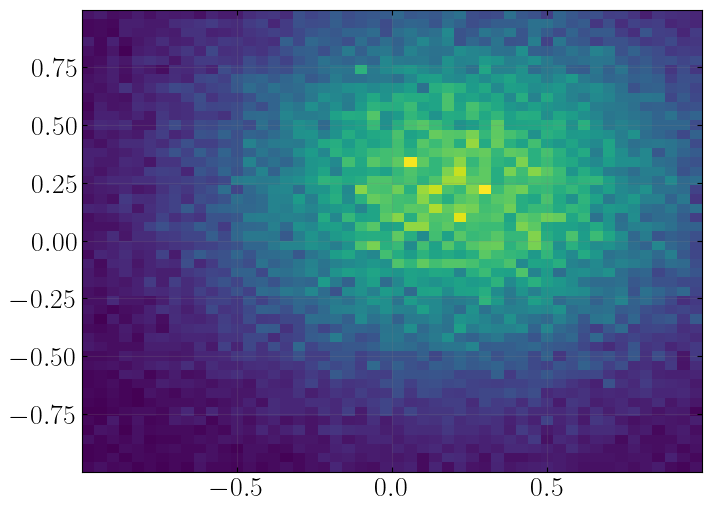

In [16]:
plt.hist2d(ct1, ct2, bins=50, density=True);

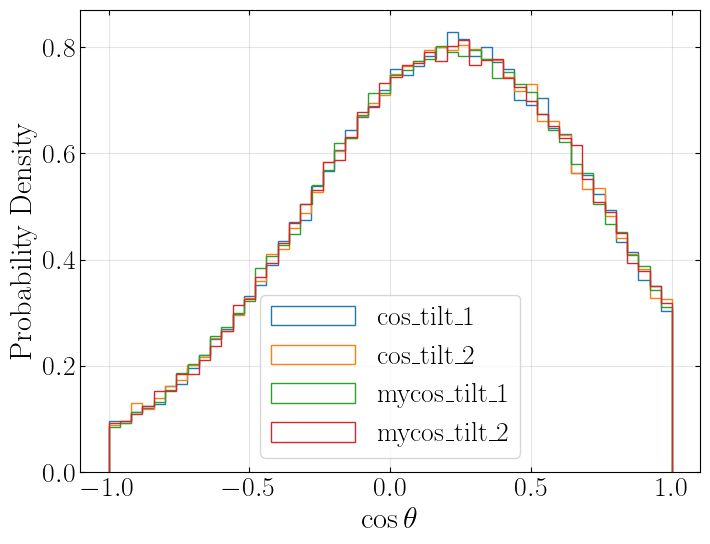

In [17]:
plt.hist(cost1, density=True, bins=50, histtype='step', label='cos_tilt_1');
plt.hist(cost2, density=True, bins=50, histtype='step', label='cos_tilt_2');
plt.hist(ct1, density=True, bins=50, histtype='step', label='mycos_tilt_1');
plt.hist(ct2, density=True, bins=50, histtype='step', label='mycos_tilt_2');
plt.xlabel(r'$\cos \theta$')
plt.ylabel('Probability Density')
plt.legend()
plt.show()